# ROMS_HIIG data set exploration w/ netcdf format 

In [40]:
import xarray as xr 
import numpy as np 
from scipy.spatial import cKDTree
from datetime import datetime, time, timezone  
import matplotlib.pyplot as plt

file = "roms_hiig_aff2_0490_90d5.nc"

ds = xr.open_dataset(file) 

ds

<xarray.Dataset> Size: 124kB
Dimensions:    (time: 49, depth: 1, latitude: 15, longitude: 21)
Coordinates:
  * time       (time) datetime64[ns] 392B 2025-12-18 ... 2025-12-24
  * depth      (depth) float32 4B 0.25
  * latitude   (latitude) float32 60B 20.54 20.57 20.61 ... 20.97 21.0 21.04
  * longitude  (longitude) float32 84B -156.7 -156.7 -156.6 ... -156.0 -155.9
Data variables:
    u          (time, depth, latitude, longitude) float32 62kB ...
    v          (time, depth, latitude, longitude) float32 62kB ...
Attributes: (12/68)
    _CoordSysBuilder:              ucar.nc2.dataset.conv.CF1Convention
    acknowledgement:               The Pacific Islands Ocean Observing System...
    cdm_data_type:                 Grid
    comment:                       Model runs produced by Brian Powell (powel...
    Conventions:                   CF-1.6, ACDD-1.3
    creator_email:                 powellb@hawaii.edu
    ...                            ...
    testOutOfDate:                 now+5days
    time_coverage_end:             2025-12-24T00:00:00Z
    time_coverage_resolution:      PT3H
    time_coverage_start:           2025-12-18T00:00:00Z
    title:                         Regional Ocean Modeling System (ROMS): Mai...
    Westernmost_Easting:           -156.71298

In [41]:
surf_spots = [
    # HOOKIPA
    # 20.934244°N 156.359621°W 

    # DUMPS 
    # 20.612921°N 156.438039°W or 203.561961  

    # OFFSHORE North east to test currents data
    # 20.9406666667, -156.0708333333
    {
        "id": 1, 
        "latitude": 20.9342,
        "longitude": -156.3596,
    }, 
    {
        "id": 2, 
        "latitude": 20.6129,
        "longitude": -156.4380,
    },   
    {
        "id": 3, 
        "latitude": 20.9410,
        "longitude": -156.0708,
    },             
]

surf_spot_ids = np.array([surf_spot["id"] for surf_spot in surf_spots])
surf_spot_lats = np.array([surf_spot["latitude"] for surf_spot in surf_spots])
surf_spot_lons = np.array([(surf_spot["longitude"]) for surf_spot in surf_spots])

### custom logic for nearest neighbor search with kdTree

In [42]:
def build_ocean_kdtree(ds, var="u", depth_idx=0): 
    # creates valid mask by checking if u-velocity component is NAN, 
    # 1 var mask is better than checking 9 data vars
    # and honestly if model run fails for a point, fine to 
    # have the mask like this.  
    
    # select first time and first depth for valid mask
    valid_mask = ~ds[var].isel(time=0, depth=0).isnull() 

    # get all lat/long grid points, extract only valid ocean points
    lat_grid, lon_grid = np.meshgrid(ds.latitude, ds.longitude, indexing="ij") 
    ocean_lats = lat_grid[valid_mask.values] 
    ocean_lons = lon_grid[valid_mask.values]

    # convert to radians for haversine 
    ocean_coords_rad = np.column_stack([
        np.radians(ocean_lats), 
        np.radians(ocean_lons)
    ]) 

    # build kd-tree
    tree = cKDTree(ocean_coords_rad)

    return tree, ocean_lats, ocean_lons

def query_nearest_ocean_points(tree, ocean_lats, ocean_longs, target_lats, target_lons): 
    target_coords_rad = np.column_stack([
        np.radians(target_lats), 
        np.radians(target_lons)
    ]) 

    # query for distances and their indices 
    distances, indicies = tree.query(target_coords_rad) 

    # get selected coords 
    selected_lats = ocean_lats[indicies] 
    selected_lons = ocean_lons[indicies] 
    distances_km = distances * 6371

    return selected_lats, selected_lons, distances_km 

In [43]:
tree, ocean_lats, ocean_lons = build_ocean_kdtree(ds, var="u") 

selected_lats, selected_lons, distances_km = query_nearest_ocean_points(
    tree,
    ocean_lats, 
    ocean_lons, 
    surf_spot_lats,   
    surf_spot_lons
)
pacioos_roms_maui = ds.sel(
        latitude=xr.DataArray(selected_lats, dims="surf_spot"),
        longitude=xr.DataArray(selected_lons, dims="surf_spot"), 
        depth=[2.50e-01]
    ).assign_coords(
        surf_spot_id=("surf_spot", surf_spot_ids),
        surf_spot_lat=("surf_spot", surf_spot_lats),
        surf_spot_lon=("surf_spot", surf_spot_lons)
    ).rename(
        {"latitude": "selected_lat", "longitude": "selected_lon",}
    )

pacioos_roms_maui

<xarray.Dataset> Size: 2kB
Dimensions:        (time: 49, depth: 1, surf_spot: 3)
Coordinates:
  * time           (time) datetime64[ns] 392B 2025-12-18 ... 2025-12-24
  * depth          (depth) float32 4B 0.25
    selected_lat   (surf_spot) float32 12B 20.97 20.61 20.93
    selected_lon   (surf_spot) float32 12B -156.4 -156.4 -156.1
    surf_spot_id   (surf_spot) int64 24B 1 2 3
    surf_spot_lat  (surf_spot) float64 24B 20.93 20.61 20.94
    surf_spot_lon  (surf_spot) float64 24B -156.4 -156.4 -156.1
Dimensions without coordinates: surf_spot
Data variables:
    u              (time, depth, surf_spot) float32 588B ...
    v              (time, depth, surf_spot) float32 588B ...
Attributes: (12/68)
    _CoordSysBuilder:              ucar.nc2.dataset.conv.CF1Convention
    acknowledgement:               The Pacific Islands Ocean Observing System...
    cdm_data_type:                 Grid
    comment:                       Model runs produced by Brian Powell (powel...
    Conventions:                   CF-1.6, ACDD-1.3
    creator_email:                 powellb@hawaii.edu
    ...                            ...
    testOutOfDate:                 now+5days
    time_coverage_end:             2025-12-24T00:00:00Z
    time_coverage_resolution:      PT3H
    time_coverage_start:           2025-12-18T00:00:00Z
    title:                         Regional Ocean Modeling System (ROMS): Mai...
    Westernmost_Easting:           -156.71298

### Plotting currents data 

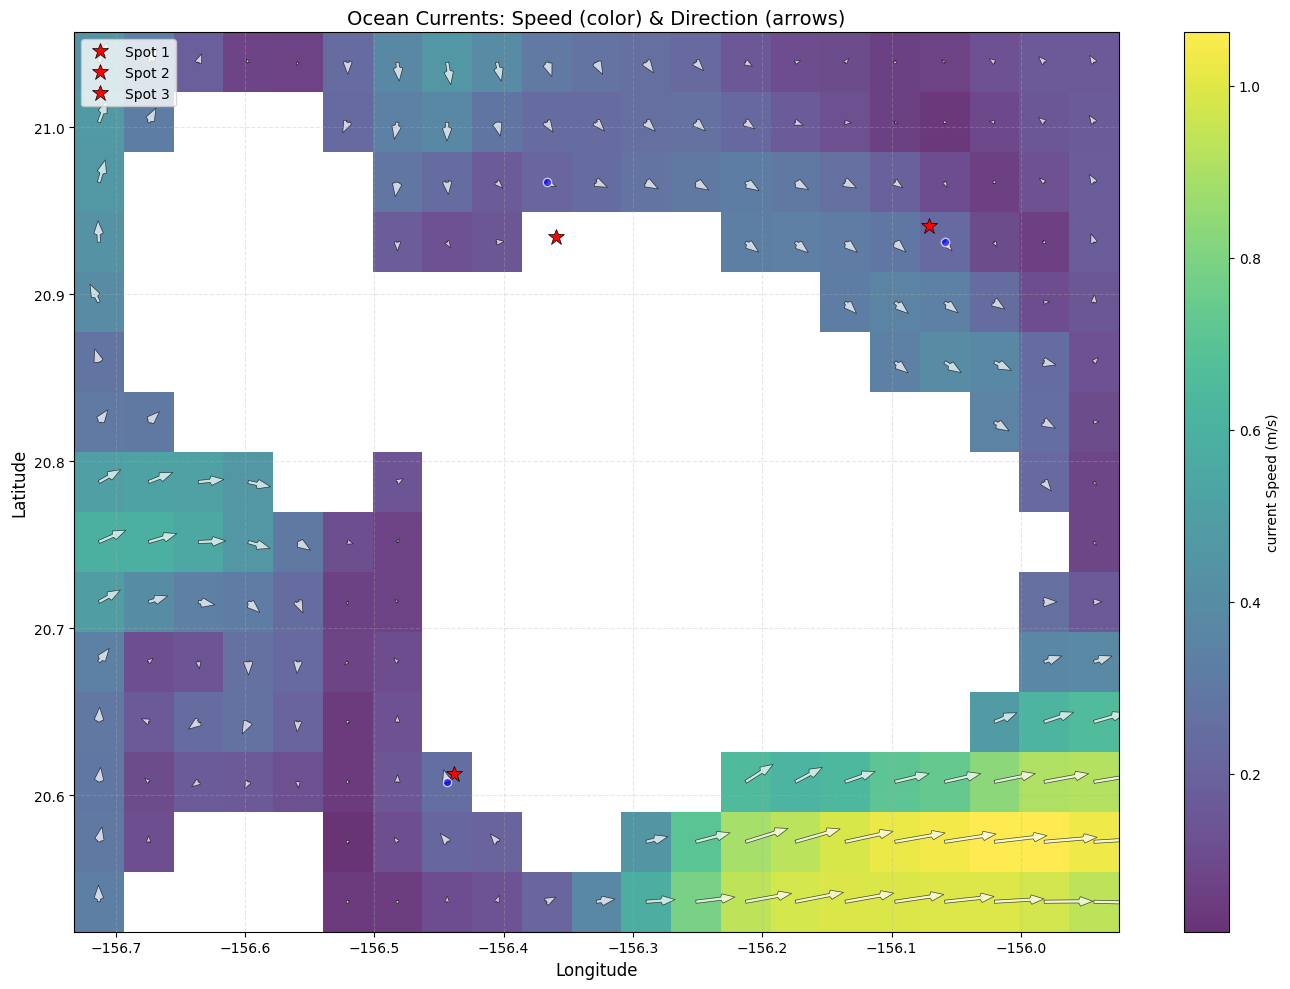

In [44]:
fc_sample = ds.isel(time=5, depth=0)

# calculate current speed (magnitude)
u = fc_sample.u.values
v = fc_sample.v.values
speed = np.sqrt(u**2 + v**2)

# calculate direction in degrees (0° = East, 90° = North)
direction_rad = np.arctan2(v, u)
direction_deg = np.degrees(direction_rad)

fig, ax = plt.subplots(figsize=(14, 10))

mesh = ax.pcolormesh(ds.longitude, ds.latitude, speed, 
                     shading='auto', cmap='viridis', alpha=0.8)
cbar = plt.colorbar(mesh, ax=ax, label='current Speed (m/s)')

# add arrows for direction, sub sample for clarity
skip = 1  # use every grid point, change to 2 or 3 for sparser arrows
lon_grid, lat_grid = np.meshgrid(ds.longitude, ds.latitude)

quiver = ax.quiver(lon_grid[::skip, ::skip], 
                   lat_grid[::skip, ::skip],
                   u[::skip, ::skip], 
                   v[::skip, ::skip],
                   scale=2,  # adjust to change arrow length
                   scale_units='inches',
                   width=0.003,
                   headwidth=3,
                   headlength=4,
                   color='white',
                   alpha=0.7,
                   edgecolors='black',
                   linewidth=0.5)

# add a quiver key (reference arrow)
ax.quiverkey(quiver, 0.9, 1.05, 0.5, '0.5 m/s', 
             labelpos='E', coordinates='axes')

# plot surf spots
for i, spot in enumerate(surf_spots):
    ax.plot(surf_spot_lons[i], surf_spot_lats[i], 'r*', 
            markersize=12, markeredgecolor='black', markeredgewidth=0.5,
            label=f"Spot {spot['id']}")
    ax.plot(pacioos_roms_maui.selected_lon.values[i], 
            pacioos_roms_maui.selected_lat.values[i],
            'bo', markersize=6, alpha=0.7, markeredgecolor='white')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Ocean Currents: Speed (color) & Direction (arrows)', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()